
BLOCO_4_BACKTESTING_ESTRATEGIA_SIMPLES

PASSO_1

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

dados = yf.download("MSFT", start="2021-01-01", end="2026-06-30")
dados = dados[["Close"]].dropna()
print(dados.head())

[*********************100%***********************]  1 of 1 completed

Price            Close
Ticker            MSFT
Date                  
2021-01-04  207.956116
2021-01-05  208.156708
2021-01-06  202.759384
2021-01-07  208.529297
2021-01-08  209.799835


Calcular médias moveis

In [8]:
dados["MM_Curta"] = dados["Close"].rolling(window=20).mean()
dados["MM_Longa"] = dados["Close"].rolling(window=50).mean()
print(dados["MM_Longa"])


Date
2021-01-04           NaN
2021-01-05           NaN
2021-01-06           NaN
2021-01-07           NaN
2021-01-08           NaN
                 ...    
2026-06-23    412.419390
2026-06-24    412.057803
2026-06-25    411.269195
2026-06-26    410.521970
2026-06-29    409.506335
Name: MM_Longa, Length: 1377, dtype: float64


Compra/Venda_Visualizar Sinais

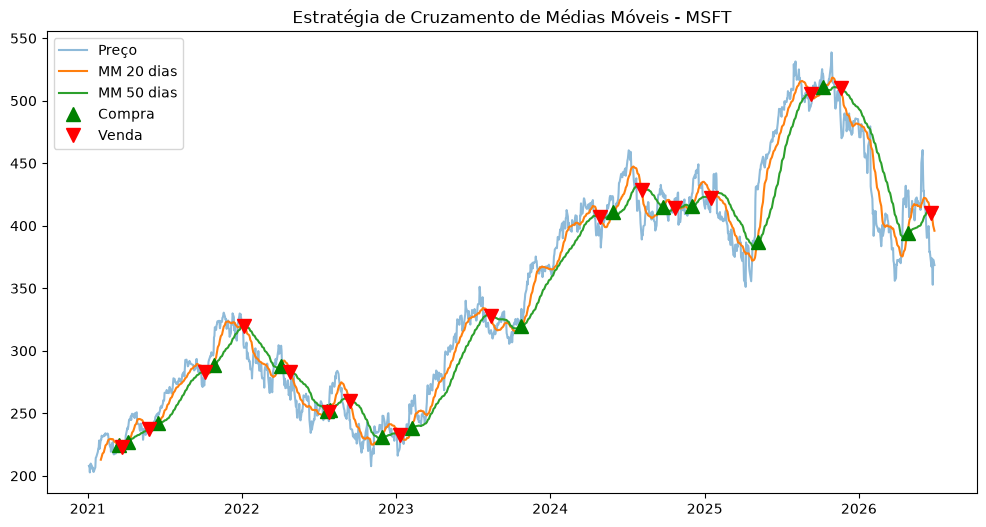

In [10]:
dados["Sinal"] = 0
dados.loc[dados["MM_Curta"] > dados["MM_Longa"], "Sinal"] = 1
dados["Posicao"] = dados["Sinal"].diff()

plt.figure(figsize=(12,6))
plt.plot(dados["Close"], label="Preço", alpha=0.5)
plt.plot(dados["MM_Curta"], label="MM 20 dias")
plt.plot(dados["MM_Longa"], label="MM 50 dias")

plt.plot(dados[dados["Posicao"] == 1].index, dados["MM_Curta"][dados["Posicao"] == 1], "^", color="green", markersize=10, label="Compra")
plt.plot(dados[dados["Posicao"] == -1].index, dados["MM_Curta"][dados["Posicao"] == -1], "v", color="red", markersize=10, label="Venda")

plt.legend()
plt.title("Estratégia de Cruzamento de Médias Móveis - MSFT")
plt.show()

Calcular retorno da estrategia

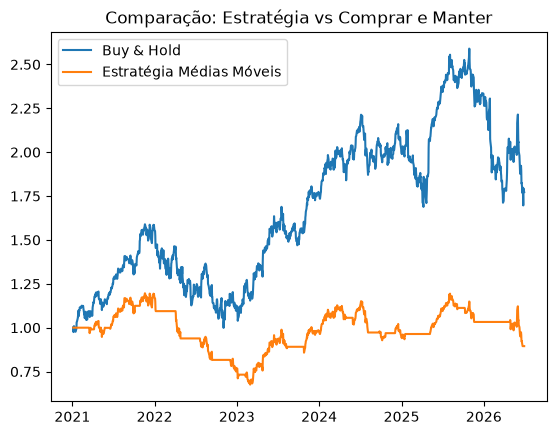

In [11]:
dados["Retorno_Diario"] = dados["Close"].pct_change()
dados["Retorno_Estrategia"] = dados["Retorno_Diario"] * dados["Sinal"].shift(1)

retorno_acumulado_bh = (1 + dados["Retorno_Diario"]).cumprod()
retorno_acumulado_estrategia = (1 + dados["Retorno_Estrategia"]).cumprod()

plt.plot(retorno_acumulado_bh, label="Buy & Hold")
plt.plot(retorno_acumulado_estrategia, label="Estratégia Médias Móveis")
plt.legend()
plt.title("Comparação: Estratégia vs Comprar e Manter")
plt.show()

As médias móveis são indicadores atrasados (lagging indicators). Quando elas cruzam confirmando uma alta, a ação já subiu um pouco. Quando elas cruzam confirmando a queda, a ação já caiu. Como a Microsoft teve um movimento muito forte de alta a longo prazo, toda vez que o seu algoritmo vendia a ação tentando se proteger, ele perdia o início da próxima grande alta e pagava taxas/corretagens por operar demais.

As médias móveis são ótimas para rastrear tendências, mas usá-las de forma pura e isolada para automatizar compras e vendas em ações de crescimento (como a MSFT) costuma gerar esse resultado. É por isso que os traders costumam combiná-las com outros indicadores (como o IFR/RSI ou o Volume).

EXERCISE_PRACTICE
Repete todo o processo para um ativo diferente do teu portefólio real (ação ou ETF).

Testa combinações diferentes de janelas (ex: 10/30 dias em vez de 20/50) e compara os resultados finais.

Calcula o retorno total da estratégia vs buy & hold usando retorno_acumulado.iloc[-1] - 1.

Reflete: a estratégia superou o buy & hold neste ativo e período? Isto já é uma pergunta central em qualquer análise quantitativa.

[*********************100%***********************]  1 of 1 completed


Price          Close
Ticker       GALP.LS
Date                
2021-01-04  6.806579
2021-01-05  7.194153
2021-01-06  7.407160
2021-01-07  7.469620
2021-01-08  7.455206


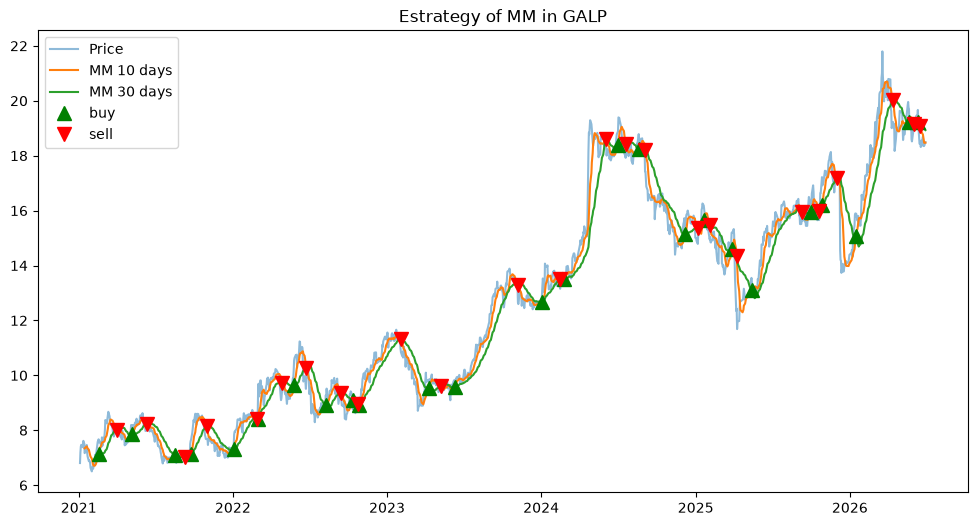

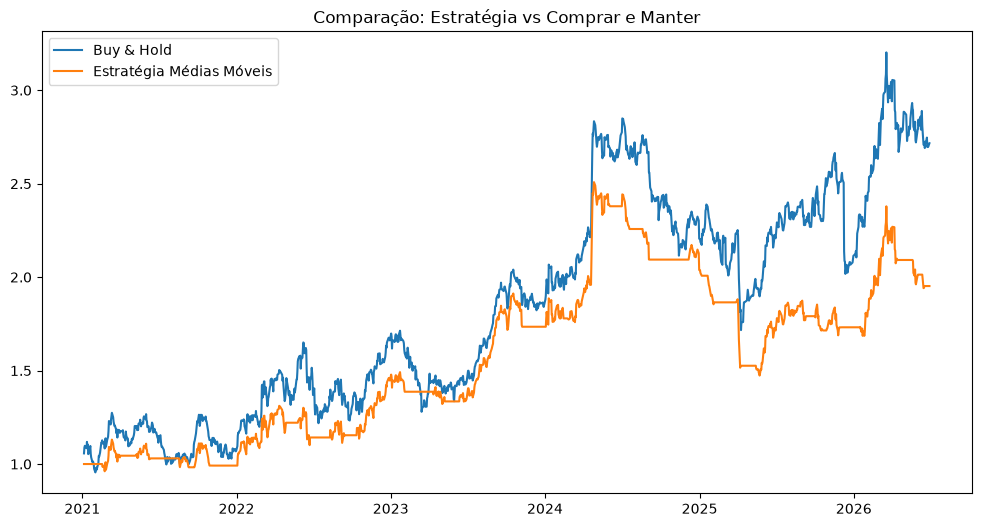

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

data = yf.download("GALP.LS", start="2021-01-01", end="2026-06-30")
data = data[["Close"]].dropna()
print(data.head())

data["MM_short"]= data["Close"].rolling(window=10).mean()
data["MM_long"]= data["Close"].rolling(window=30).mean()

data["Sinal"]=0
data.loc[data["MM_short"]> data["MM_long"], "Sinal"] = 1
data["Position"]= data["Sinal"].diff()

plt.figure(figsize=(12,6))
plt.plot(data["Close"], label="Price", alpha=0.5)
plt.plot(data["MM_short"], label="MM 10 days")
plt.plot(data["MM_long"], label="MM 30 days")

plt.plot(data[data["Position"] == 1].index, data["MM_short"][data["Position"] == 1], "^", color="green", markersize=10, label="buy")
plt.plot(data[data["Position"] == -1].index, data["MM_long"][data["Position"] == -1], "v", color="red", markersize=10, label="sell")

plt.legend()
plt.title("Estrategy of MM in GALP")
plt.show()

data["Retorno_Diario"] = data["Close"].pct_change()
data["Retorno_Estrategia"] = data["Retorno_Diario"] * data["Sinal"].shift(1)


retorno_acumulado_bh = (1 + data["Retorno_Diario"].dropna()).cumprod()
retorno_acumulado_estrategia = (1 + data["Retorno_Estrategia"].dropna()).cumprod()

plt.figure(figsize=(12,6)) 
plt.plot(retorno_acumulado_bh, label="Buy & Hold")
plt.plot(retorno_acumulado_estrategia, label="Estratégia Médias Móveis")
plt.legend()
plt.title("Comparação: Estratégia vs Comprar e Manter")
plt.show()



The Moving Average (MA) strategy performed quite well in absolute terms, delivering a solid positive return that turned an initial $1.00 investment into nearly $2.00, resulting in a 100% profit over the period. While it underperformed relative to the Buy & Hold strategy—which reached roughly $2.70 due to GALP's massive, prolonged bull run—the MA strategy showcased a crucial advantage in risk management. This is clearly visible in the flat horizontal segments of the orange line during 2022, mid-2024, and early 2025; during these market downturns and sideways trends, the strategy triggered sell signals and sidelined your capital, successfully protecting you from the losses that Buy & Hold investors had to endure. The reason it ultimately lagged behind Buy & Hold in total returns is down to the inherent nature of moving averages, which suffer from indicator lag (entering and exiting a strong trend slightly late, which shaves off profit margins) and whipsaws (false signals caused by short-term volatility). Ultimately, for a simple trend-following system, the result is highly respectable because it behaved exactly as intended: it sacrificed maximum potential gains in exchange for downside protection and peace of mind.

PASSO_2


In [26]:
pip install vectorbt

   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   --------------------------------- ------ 2.4/2.8 MB 14.8 MB/s eta 0:00:01
   ---------------------------------------- 2.8/2.8 MB 11.8 MB/s  0:00:00
   ---------------------------------------- 0.0/43.0 MB ? eta -:--:--
   -- ------------------------------------- 2.9/43.0 MB 13.6 MB/s eta 0:00:03
   ----- ---------------------------------- 5.8/43.0 MB 13.5 MB/s eta 0:00:03
   -------- ------------------------------- 8.9/43.0 MB 14.2 MB/s eta 0:00:03
   ---------- ----------------------------- 11.5/43.0 MB 13.9 MB/s eta 0:00:03
   -------------- ------------------------- 15.2/43.0 MB 14.4 MB/s eta 0:00:02
   ----------------- ---------------------- 19.1/43.0 MB 15.0 MB/s eta 0:00:02
   ---------------------- ----------------- 23.9/43.0 MB 15.9 MB/s eta 0:00:02
   ------------------------- -------------- 27.5/43.0 MB 16.1 MB/s eta 0:00:01
   ----------------------------- ---------- 31.5/43.0 MB 16.3 MB/s eta 0:00:01
  

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  You can safely remove it manually.
  You can safely remove it manually.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [ ]:
import vectorbt as vbt

dados = vbt.YFData.download("MSFT", start="2021-01-01", end="2026-06-30").get("Close")
print(dados.head())
mm_curta = vbt.MA.run(dados, window=20)
mm_longa = vbt.MA.run(dados, window=50)


Date
2020-12-31 05:00:00+00:00    212.474609
2021-01-04 05:00:00+00:00    207.956085
2021-01-05 05:00:00+00:00    208.156723
2021-01-06 05:00:00+00:00    202.759399
2021-01-07 05:00:00+00:00    208.529282
Name: Close, dtype: float64


In [5]:
entradas = mm_curta.ma_crossed_above(mm_longa)
saidas = mm_curta.ma_crossed_below(mm_longa)
portfolio = vbt.Portfolio.from_signals(
    dados,
    entradas,
    saidas,
    init_cash=10000,
    fees=0.001
)
print(portfolio.stats())
portfolio.plot().show()

C:\Users\Utilizador\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\vectorbt\generic\stats_builder.py:378: UserWarning: Metric 'sharpe_ratio' requires frequency to be set
  warnings.warn(warning_message)
C:\Users\Utilizador\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\vectorbt\generic\stats_builder.py:378: UserWarning: Metric 'calmar_ratio' requires frequency to be set
  warnings.warn(warning_message)
C:\Users\Utilizador\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\vectorbt\generic\stats_builder.py:378: UserWarning: Metric 'omega_ratio' requires frequency to be set
  warnings.warn(warning_message)
C:\Users\Utilizador\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\vectorbt\generic\stats_builder.py:378: UserWarning: Metric 'sortino_ratio' requires frequency to be set
  warnings.warn(warning_message)


Start                         2020-12-31 05:00:00+00:00
End                           2026-06-29 04:00:00+00:00
Period                                             1378
Start Value                                     10000.0
End Value                                   8767.393225
Total Return [%]                             -12.326068
Benchmark Return [%]                          73.465436
Max Gross Exposure [%]                            100.0
Total Fees Paid                                289.2178
Max Drawdown [%]                              44.065983
Max Drawdown Duration                            1153.0
Total Trades                                         15
Total Closed Trades                                  15
Total Open Trades                                     0
Open Trade PnL                                      0.0
Win Rate [%]                                  33.333333
Best Trade [%]                                21.456417
Worst Trade [%]                              -14

EXERCISE_PRACTICE
Repete o processo completo para o mesmo ativo que já usaste manualmente na Semana 14 (ex: MSFT), com as mesmas janelas (20/50).

Compara o portfolio.stats() do vectorbt com os cálculos manuais que fizeste — os retornos totais devem ser semelhantes, o que confirma que percebeste a lógica corretamente.

Experimenta alterar as janelas das médias (ex: 10/30) e observa como o Sharpe Ratio e o retorno total mudam.

Testa noutro ativo do teu interesse (ação ou ETF, sem petróleo/ouro).


In [6]:
import vectorbt as vbt

dados = vbt.YFData.download("GALP.LS", start="2021-01-01", end="2026-06-30").get("Close")
print(dados.head())
mm_curta = vbt.MA.run(dados, window=10)
mm_longa = vbt.MA.run(dados, window=30)

entradas = mm_curta.ma_crossed_above(mm_longa)
saidas = mm_curta.ma_crossed_below(mm_longa)
portfolio = vbt.Portfolio.from_signals(
    dados,
    entradas,
    saidas,
    init_cash=10000,
    fees=0.001
)
print(portfolio.stats())
portfolio.plot().show()

Date
2020-12-31 00:00:00+00:00    7.009976
2021-01-04 00:00:00+00:00    6.806580
2021-01-05 00:00:00+00:00    7.194153
2021-01-06 00:00:00+00:00    7.407159
2021-01-07 00:00:00+00:00    7.469620
Name: Close, dtype: float64
Start                         2020-12-31 00:00:00+00:00
End                           2026-06-28 23:00:00+00:00
Period                                             1406
Start Value                                     10000.0
End Value                                  18570.697298
Total Return [%]                              85.706973
Benchmark Return [%]                         163.766934
Max Gross Exposure [%]                            100.0
Total Fees Paid                              759.230908
Max Drawdown [%]                              41.963387
Max Drawdown Duration                             553.0
Total Trades                                         25
Total Closed Trades                                  25
Total Open Trades                                

C:\Users\Utilizador\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\vectorbt\generic\stats_builder.py:378: UserWarning: Metric 'sharpe_ratio' requires frequency to be set
  warnings.warn(warning_message)
C:\Users\Utilizador\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\vectorbt\generic\stats_builder.py:378: UserWarning: Metric 'calmar_ratio' requires frequency to be set
  warnings.warn(warning_message)
C:\Users\Utilizador\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\vectorbt\generic\stats_builder.py:378: UserWarning: Metric 'omega_ratio' requires frequency to be set
  warnings.warn(warning_message)
C:\Users\Utilizador\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\vectorbt\generic\stats_builder.py:378: UserWarning: Metric 'sortino_ratio' requires frequency to be set
  warnings.warn(warning_message)


PAASO_3_MOMETUM

In [11]:
import vectorbt as vbt
import numpy as np

dados = vbt.YFData.download("MSFT", start="2021-01-01", end="2026-06-30").get("Close")

In [12]:
periodo = 60
momentum = dados.pct_change(periods=periodo)

In [13]:
entradas = momentum > 0
saidas = momentum < 0

In [15]:
portfolio = vbt.Portfolio.from_signals(
    dados,
    entradas,
    saidas,
    init_cash=10000,
    fees=0.001
)

print(portfolio.stats())
buy_hold = vbt.Portfolio.from_holding(dados, init_cash=10000)

print("Momentum:", portfolio.total_return())
print("Buy & Hold:", buy_hold.total_return())

Start                         2020-12-31 05:00:00+00:00
End                           2026-06-29 04:00:00+00:00
Period                                             1378
Start Value                                     10000.0
End Value                                  11293.368722
Total Return [%]                              12.933687
Benchmark Return [%]                          73.465436
Max Gross Exposure [%]                            100.0
Total Fees Paid                              981.909136
Max Drawdown [%]                              29.544815
Max Drawdown Duration                             540.0
Total Trades                                         39
Total Closed Trades                                  39
Total Open Trades                                     0
Open Trade PnL                                      0.0
Win Rate [%]                                  23.076923
Best Trade [%]                                23.350331
Worst Trade [%]                                -

In [16]:
janelas = np.arange(20, 121, 20)
resultados = {}

for j in janelas:
    mom = dados.pct_change(periods=int(j))
    ent = mom > 0
    sai = mom < 0
    pf = vbt.Portfolio.from_signals(dados, ent, sai, init_cash=10000, fees=0.001)
    resultados[j] = pf.total_return()

print(resultados)

{np.int64(20): np.float64(-0.017024818835418773), np.int64(40): np.float64(0.036663883740467466), np.int64(60): np.float64(0.1293368721709652), np.int64(80): np.float64(0.5018883278649874), np.int64(100): np.float64(0.20255764958330036), np.int64(120): np.float64(0.5923984730196713)}


EXERCISE_PRACTICE
Aplica a estratégia de momentum a um segundo ativo (ETF ou ação diferente).

Compara os resultados de total_return() entre momentum, médias móveis (Semana 15) e buy & hold para o mesmo ativo e período.

Reflete: qual estratégia teve melhor performance neste caso específico? Isto varia consoante o ativo e período, o que já é uma lição importante sobre a fragilidade de qualquer estratégia testada num único cenário.

In [17]:
import vectorbt as vbt
import numpy as np

dados = vbt.YFData.download("GALP.LS", start="2021-01-01", end="2026-06-30").get("Close")
periodo = 60
momentum = dados.pct_change(periods=periodo)
entradas = momentum > 0
saidas = momentum < 0
portfolio = vbt.Portfolio.from_signals(
    dados,
    entradas,
    saidas,
    init_cash=10000,
    fees=0.001
)

print(portfolio.stats())
buy_hold = vbt.Portfolio.from_holding(dados, init_cash=10000)

print("Momentum:", portfolio.total_return())
print("Buy & Hold:", buy_hold.total_return())
janelas = np.arange(20, 121, 20)
resultados = {}

for j in janelas:
    mom = dados.pct_change(periods=int(j))
    ent = mom > 0
    sai = mom < 0
    pf = vbt.Portfolio.from_signals(dados, ent, sai, init_cash=10000, fees=0.001)
    resultados[j] = pf.total_return()

print(resultados)

C:\Users\Utilizador\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\vectorbt\generic\stats_builder.py:378: UserWarning: Metric 'sharpe_ratio' requires frequency to be set
  warnings.warn(warning_message)
C:\Users\Utilizador\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\vectorbt\generic\stats_builder.py:378: UserWarning: Metric 'calmar_ratio' requires frequency to be set
  warnings.warn(warning_message)
C:\Users\Utilizador\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\vectorbt\generic\stats_builder.py:378: UserWarning: Metric 'omega_ratio' requires frequency to be set
  warnings.warn(warning_message)
C:\Users\Utilizador\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\vectorbt\generic\stats_builder.py:378: UserWarning: Metric 'sortino_ratio' requires frequency to be set
  warnings.warn(warning_message)


Start                         2020-12-31 00:00:00+00:00
End                           2026-06-28 23:00:00+00:00
Period                                             1406
Start Value                                     10000.0
End Value                                  11241.510816
Total Return [%]                              12.415108
Benchmark Return [%]                         163.766934
Max Gross Exposure [%]                            100.0
Total Fees Paid                              897.793483
Max Drawdown [%]                              32.657525
Max Drawdown Duration                             581.0
Total Trades                                         41
Total Closed Trades                                  41
Total Open Trades                                     0
Open Trade PnL                                      0.0
Win Rate [%]                                  34.146341
Best Trade [%]                                33.052494
Worst Trade [%]                              -12

PASSO_4_VALLUATION

O Sharpe Ratio mede o retorno obtido por unidade de risco assumido — quanto mais alto, melhor (valores acima de 1 são considerados bons; acima de 2, muito bons).

In [19]:
import vectorbt as vbt

dados = vbt.YFData.download("MSFT", start="2021-01-01", end="2026-06-30").get("Close")

mm_curta = vbt.MA.run(dados, window=20)
mm_longa = vbt.MA.run(dados, window=50)
entradas = mm_curta.ma_crossed_above(mm_longa)
saidas = mm_curta.ma_crossed_below(mm_longa)

portfolio = vbt.Portfolio.from_signals(
    dados, entradas, saidas,
    init_cash=10000, fees=0.001, freq="1d"
)
print("Sharpe Ratio:", portfolio.sharpe_ratio())

Sharpe Ratio: -0.0731277845477954


O Max Drawdown mostra a maior queda percentual desde um pico até um vale, ao longo de todo o período — é a "pior experiência" que um investidor teria vivido com esta estratégia.Um Max Drawdown de -25% significa que, no pior momento, a carteira perdeu 25% do seu valor de pico antes de recuperar.

In [20]:
print("Max Drawdown:", portfolio.max_drawdown())

Max Drawdown: -0.44065982847364027


In [21]:
print(portfolio.stats())

Start                         2020-12-31 05:00:00+00:00
End                           2026-06-29 04:00:00+00:00
Period                               1378 days 00:00:00
Start Value                                     10000.0
End Value                                   8767.393225
Total Return [%]                             -12.326068
Benchmark Return [%]                          73.465436
Max Gross Exposure [%]                            100.0
Total Fees Paid                                289.2178
Max Drawdown [%]                              44.065983
Max Drawdown Duration                1153 days 00:00:00
Total Trades                                         15
Total Closed Trades                                  15
Total Open Trades                                     0
Open Trade PnL                                      0.0
Win Rate [%]                                  33.333333
Best Trade [%]                                21.456417
Worst Trade [%]                              -14

In [22]:
portfolio.drawdowns.plot().show()

In [23]:
buy_hold = vbt.Portfolio.from_holding(dados, init_cash=10000, freq="1d")

comparacao = {
    "Estrategia": ["Medias Moveis", "Buy & Hold"],
    "Retorno Total": [portfolio.total_return(), buy_hold.total_return()],
    "Sharpe Ratio": [portfolio.sharpe_ratio(), buy_hold.sharpe_ratio()],
    "Max Drawdown": [portfolio.max_drawdown(), buy_hold.max_drawdown()]
}

import pandas as pd
print(pd.DataFrame(comparacao))

      Estrategia  Retorno Total  Sharpe Ratio  Max Drawdown
0  Medias Moveis      -0.123261     -0.073128     -0.440660
1     Buy & Hold       0.734654      0.615914     -0.371485


EXERCICIO_PRATICO_6

Aplica esta avaliação completa (Sharpe, drawdown, comparação) à tua estratégia de momentum da Semana 16.

Cria uma tabela final comparando as 3 abordagens (médias móveis, momentum, buy & hold) num único ativo.

Escreve 2-3 frases de conclusão: qual estratégia teve melhor relação risco-retorno, e isso mudou a tua perceção em relação a olhar só para o retorno total?

Sobe este notebook final para o GitHub, fechando oficialmente o teu segundo projeto de portfolio ("Backtester de médias móveis").


In [25]:
import vectorbt as vbt

dados = vbt.YFData.download("GALP.LS", start="2021-01-01", end="2026-06-30").get("Close")

mm_curta = vbt.MA.run(dados, window=20)
mm_longa = vbt.MA.run(dados, window=50)
entradas = mm_curta.ma_crossed_above(mm_longa)
saidas = mm_curta.ma_crossed_below(mm_longa)

portfolio = vbt.Portfolio.from_signals(
    dados, entradas, saidas,
    init_cash=10000, fees=0.001, freq="1d"
)
print("Sharpe Ratio:", portfolio.sharpe_ratio())
print("Max Drawdown:", portfolio.max_drawdown())
print(portfolio.stats())
portfolio.drawdowns.plot().show()
buy_hold = vbt.Portfolio.from_holding(dados, init_cash=10000, freq="1d")

comparacao = {
    "Estrategia": ["Medias Moveis", "Buy & Hold"],
    "Retorno Total": [portfolio.total_return(), buy_hold.total_return()],
    "Sharpe Ratio": [portfolio.sharpe_ratio(), buy_hold.sharpe_ratio()],
    "Max Drawdown": [portfolio.max_drawdown(), buy_hold.max_drawdown()]
}

import pandas as pd
print(pd.DataFrame(comparacao))

Sharpe Ratio: 0.4563689963365505
Max Drawdown: -0.34326163144085664
Start                         2020-12-31 00:00:00+00:00
End                           2026-06-28 23:00:00+00:00
Period                               1406 days 00:00:00
Start Value                                     10000.0
End Value                                  14139.120481
Total Return [%]                              41.391205
Benchmark Return [%]                         163.766934
Max Gross Exposure [%]                            100.0
Total Fees Paid                              313.509911
Max Drawdown [%]                              34.326163
Max Drawdown Duration                 517 days 00:00:00
Total Trades                                         14
Total Closed Trades                                  14
Total Open Trades                                     0
Open Trade PnL                                      0.0
Win Rate [%]                                       50.0
Best Trade [%]                      

      Estrategia  Retorno Total  Sharpe Ratio  Max Drawdown
0  Medias Moveis       0.413912      0.456369     -0.343262
1     Buy & Hold       1.637669      0.855645     -0.397461


In [ ]:
import vectorbt as vbt

dados = vbt.YFData.download("MSFT", start="2021-01-01", end="2026-06-30").get("Close")

mm_curta = vbt.MA.run(dados, window=20)
mm_longa = vbt.MA.run(dados, window=50)
entradas = mm_curta.ma_crossed_above(mm_longa)
saidas = mm_curta.ma_crossed_below(mm_longa)

portfolio = vbt.Portfolio.from_signals(
    dados, entradas, saidas,
    init_cash=10000, fees=0.001, freq="1d"
)
print("Sharpe Ratio:", portfolio.sharpe_ratio())

Sharpe Ratio: -0.0731277845477954
